# Outliers in L23

In [1]:
# imports

from importlib import reload

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from oceancolor.tara import io as tara_io
from oceancolor.ph import pigments
from oceancolor.hydrolight import loisel23

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io

In [2]:
%matplotlib ipympl

# Load

## NMF

In [3]:
nmf_fit = 'L23'
N_NMF, iop = 4, 'a'
d_L23 = cnmf_io.load_nmf(nmf_fit, N_NMF, iop)
L23_M = d_L23['M']
L23_coeff = d_L23['coeff']
L23_NMF_wave = d_L23['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/L23/L23_NMF_04_a.npz


# Reconstruct em

In [4]:
recon = np.dot(d_L23['coeff'], d_L23['M'])

# RMSE

## Restrict to true values above a mininum

In [13]:
np.sum(~anly)

94394

In [7]:
diff = recon - d_L23['spec']

In [11]:
RMSE = np.sqrt(np.mean(diff**2, axis=1))

## Plot

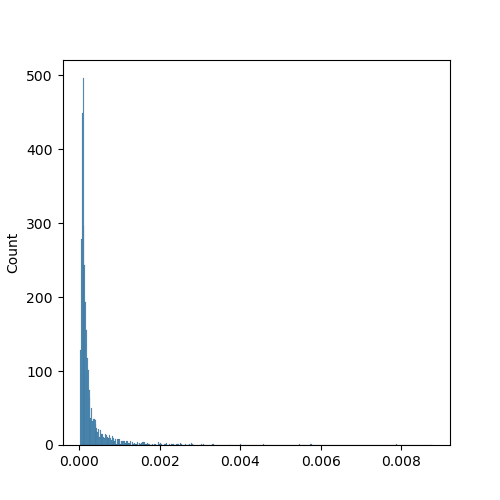

In [15]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()
_ = sns.histplot(RMSE)
#
plt.show()

## Extrema

In [16]:
srt_RMSE = np.argsort(RMSE)
high_RMSE = srt_RMSE[-10:]

## Plot a few

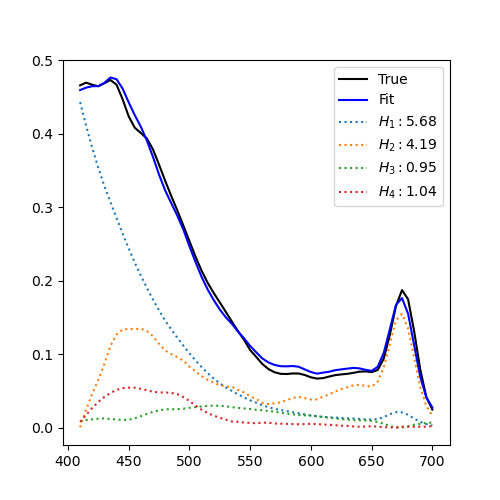

RMSE = 0.008780274164909622, idx=2298


In [64]:
idx = high_RMSE[-1]
d = d_L23

fig = plt.figure(figsize=(5,5))
ax = plt.gca()

ax.plot(d['wave'], d['spec'][idx], 'k-', label='True')
ax.plot(d['wave'], recon[idx], 'b-', label='Fit')

# Break it down
for ss in range(d['M'].shape[0]):
    ax.plot(d['wave'], d['M'][ss]*d['coeff'][idx][ss], 
            label=r'$H_'+f'{ss+1}: {d["coeff"][idx][ss]:0.2f}'+'$', ls=':')

ax.legend()
plt.show()
print(f'RMSE = {RMSE[idx]}, idx={idx}')

# Relative RMSE

In [63]:
save = [1245,  # Very low absorption; funny Chl-a and absorption near it
        2781,  # Strong absorption; small differences throughout
        2298,  # High RMSE; differences throughout
       ]

In [56]:
anly = d_L23['spec'] > 0.005
cut_diff = diff.copy()
cut_diff[~anly] = np.nan  
rRMSE = np.sqrt(np.nanmean((cut_diff/recon)**2, axis=1))

/tmp/ipykernel_24171/3793923071.py:4: RuntimeWarning: Mean of empty slice
  rRMSE = np.sqrt(np.nanmean((cut_diff/recon)**2, axis=1))


In [57]:
srt_rRMSE = np.argsort(rRMSE)
high_rRMSE = srt_rRMSE[-10:]

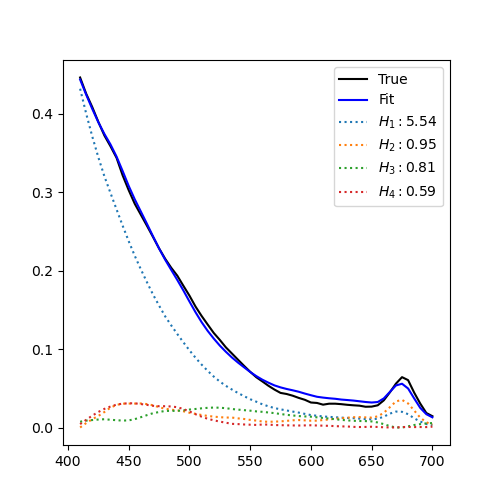

rRMSE = 0.11344139498828992


In [62]:
idx = high_rRMSE[3]
#idx = 2748
idx = 2781
d = d_L23

fig = plt.figure(figsize=(5,5))
ax = plt.gca()

ax.plot(d['wave'], d['spec'][idx], 'k-', label='True')
ax.plot(d['wave'], recon[idx], 'b-', label='Fit')

# Break it down
for ss in range(d['M'].shape[0]):
    ax.plot(d['wave'], d['M'][ss]*d['coeff'][idx][ss], 
            label=r'$H_'+f'{ss+1}: {d["coeff"][idx][ss]:0.2f}'+'$', ls=':')

ax.legend()
plt.show()
print(f'rRMSE = {rRMSE[idx]}')

In [59]:
np.median(rRMSE)

nan

## Find the strongest in the top 50

In [60]:
i440 = np.argmin(np.abs(d['wave']-440.))
maxI = -1
high_a = 0.
for idx in srt_rRMSE[-50:]:
    if recon[idx,i440] > high_a:
        high_a = recon[idx,i440] 
        maxI = idx
print(maxI)

2781


----

In [30]:
ds = loisel23.load_ds(4,0)

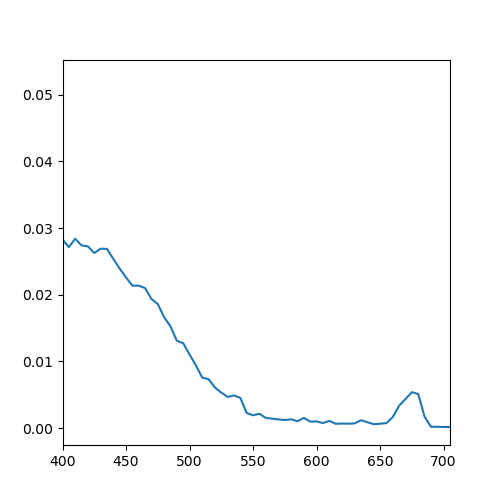

In [33]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()

ax.plot(ds.Lambda, ds.anw.data[idx])

ax.set_xlim(400., 705)

plt.show()